# Tarea Semanal 1
## Teoría de Circuitos II
### Alumno
#### Juan Manuel Miranda Del Valle

### Institución
#### Universidad Tecnologica Nacional

### Profesores
#### Mariano Llamedo Soria y César Fouco

## Consignas

<div align="center">
    <img src="Captura de pantalla 2026-05-19 113311.png" width="1100">
</div>

<div align="center">
    <img src="Captura de pantalla 2026-05-19 113323.png" width="1100">
</div>

## Ejercicio 1

<div align="center">
    <img src="Captura de pantalla 2026-05-19 113944.png" width="1100">
</div>

### Planteo Nodos

$$
Nodo A: 0=-V1 . G1 - VB . (G2+SC) - V2 . G3
$$
$$
Nodo C: 0= -VB . G3 + V2 . SC \Rightarrow VB = \frac{V2 . SC}{G3}
$$

#### Entonces reemplazando
$$
\frac{V2}{V1}=\frac{\frac{-R3}{R1} . \frac{1}{R3^2 . C^2}}{S^2+S \frac{1}{CR2}+\frac{1}{R3^2 . C^2}}
$$

$$
\frac{V2}{V1}=\frac{K . Wo^2}{S^2+S \frac{Wo}{Q}+Wo^2}
$$

### Adjunto resolucion completa con todos los despejes correspondientes
<div align="center">
    <img src="Captura de pantalla 2026-05-19 121634.png" width="1100">
</div>


## Ejercicio 2

$$
K = \frac{-R3}{R1}
$$
$$
Wo = \frac{1}{R3 . C}
$$
$$
\frac{Wo}{Q} = \frac{-R3}{R1} \Rightarrow Q=\frac{R2}{R3}
$$

## Ejercicio 3 

#### Se puede hacer un pasabanda tomando como voltaje de salida el nodo B

<div align="center">
    <img src="Captura de pantalla 2026-05-19 113944.png" width="1100">
</div>

#### Y usando de la resolucion anterior  

$$
Nodo C: 0= -VB . G3 + V2 . SC \Rightarrow VB = \frac{V2 . SC}{G3}
$$

$$
V2=\frac{V1 . \frac{-R3}{R1} . \frac{1}{R3^2 . C^2}}{S^2+S \frac{1}{CR2}+\frac{1}{R3^2 . C^2}}
$$
$$
VB=\frac{V1 . \frac{-1}{R1 . C}}{S^2+S \frac{1}{CR2}+\frac{1}{R3^2 . C^2}}
$$
$$
\frac{V2}{V1}=\frac{\frac{-R2}{R1} .S. \frac{1}{CR2}}{S^2+S \frac{1}{CR2}+\frac{1}{R3^2 . C^2}}
$$
$$
K = \frac{-R2}{R1}
$$
$$
Wo = \frac{1}{R3 . C}
$$
$$
\frac{Wo}{Q} = \frac{-R3}{R1} \Rightarrow Q=\frac{R2}{R3}
$$

## Ejercicio 4

Saco epsilon y el orden del filtro

<div align="center">
    <img src="Captura de pantalla 2026-05-19 134437.png" width="1100">
</div>

Me queda que el filtro tiene que ser de orden 5 para cumplir con los requerimientos de atenuacion pedidos


Saco la transferencia del filtro

<div align="center">
    <img src="Captura de pantalla 2026-05-19 134459.png" width="1100">
</div>

### Compruebo con python




In [2]:
import numpy as np
from scipy import signal as sig
import sympy as sp
from matplotlib import pyplot as plt
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys

orden = 5
ripple = 0.4

eps = np.sqrt(10**(ripple/10) - 1)

s = sp.symbols("S", real=True, positive=True)

omega = sp.symbols("W", real=True, positive=True)

epss = sp.symbols("ε", real=True, positive=True)

C5=16*omega**5-20*omega**3-5*omega

TT=1/(1+epss**2*C5**2)
TT=sp.expand(TT)
print_latex(a_equal_b_latex_s('|T(S)||T(-S)|=',TT))


<IPython.core.display.Math object>

In [4]:
TT=(1/(epss**2*256))/(s**(10)+640/256*s**8+560/256*s**6+200/256*s**4+25/256*s**2-1/(epss**2*256))
print_latex(a_equal_b_latex_s('|T(S)||T(-S)|=',TT))

<IPython.core.display.Math object>

In [8]:
den = np.array([1, 0, 640/256, 0, 560/256, 0, 200/256, 0 , 25/256, 0 , -1/256/ eps**2])
polos=np.roots(den)
polos=polos[np.real(polos) < 0]
print(polos)

[-0.11932228+1.01949544j -0.11932228-1.01949544j -0.31238979+0.63008283j
 -0.31238979-0.63008283j -0.38613502+0.j        ]


### Con los polos armo 2 transferencias de orden 2 y una de orden 1



<div align="center">
    <img src="Captura de pantalla 2026-05-19 161534.png" width="1100">
</div>

In [11]:
T1=1.05359/(s**2+s*0.2386+1.05359)
T2=0.4946/(s**2+s*0.6248+0.4946)
T3=0.3861/(s+0.3861)

Ttot=T1*T2*T3
Ttot=sp.expand(Ttot)

print_latex(a_equal_b_latex_s('T(S)=',Ttot))

<IPython.core.display.Math object>

array([-0.11930455+1.0194885j , -0.11930455-1.0194885j ,
       -0.31237987+0.63006466j, -0.31237987-0.63006466j,
       -0.38613117+0.j        ])

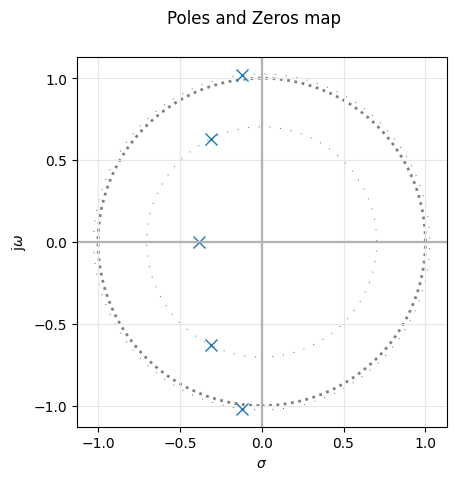

In [12]:
num=np.array([0.2012])
den=np.array([1,1.2495,2.0306,1.4316,0.8208,0.2012])

T = sig.TransferFunction(num, den)

pzmap(T)

plt.show

np.roots(den)

### Ahora desnormalizo en frecuencia y le doy valores a los componentes

Al final use Capacitores de 10nF asi que en el circuito se van a ver que los valores de Resistencias son un orden mas chicos


<div align="center">
    <img src="Captura de pantalla 2026-05-19 163531.png" width="1100">
</div>

<div align="center">
    <img src="Captura de pantalla 2026-05-19 164411.png" width="1100">
</div>

### Adjunto simulacion de Spice en la que se ve que la respuesta en frecuencia cumple con lo pedido

<div align="center">
    <img src="Captura de pantalla 2026-05-19 164852.png" width="1100">
</div>

<div align="center">
    <img src="Captura de pantalla 2026-05-19 164947.png" width="500">
</div>

#### Se puede observar que cumple con los 0.4dB de riple en 3200Hz y tambien cumple con la atenuacion a 9600Hz